***Chemical Code that runs by saving file.***

<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1717837030.py:41: SyntaxWarning: invalid escape sequence '\s'
  df_output = pd.read_csv("lab1_output.txt", sep='\s+', skiprows=1, names=['time', 'c1', 'c2', 'c3'])


Simulating reaction of chemicals c1, c2 and c3...
Simulation completed. File saved as lab1_output.txt.

Reading the generated file 'lab1_output.txt':


,time,c1,c2,c3
0,0.000,70.000000,30.000000,0.000000
1,0.001,69.947500,29.947500,0.105000
2,0.002,69.895132,29.895132,0.209736
3,0.003,69.842896,29.842896,0.314208
4,0.004,69.790792,29.790792,0.418417
...,...,...,...,...
195,0.195,61.797125,21.797125,16.405750
196,0.196,61.763614,21.763614,16.472772
197,0.197,61.730174,21.730174,16.539652
198,0.198,61.696804,21.696804,16.606392


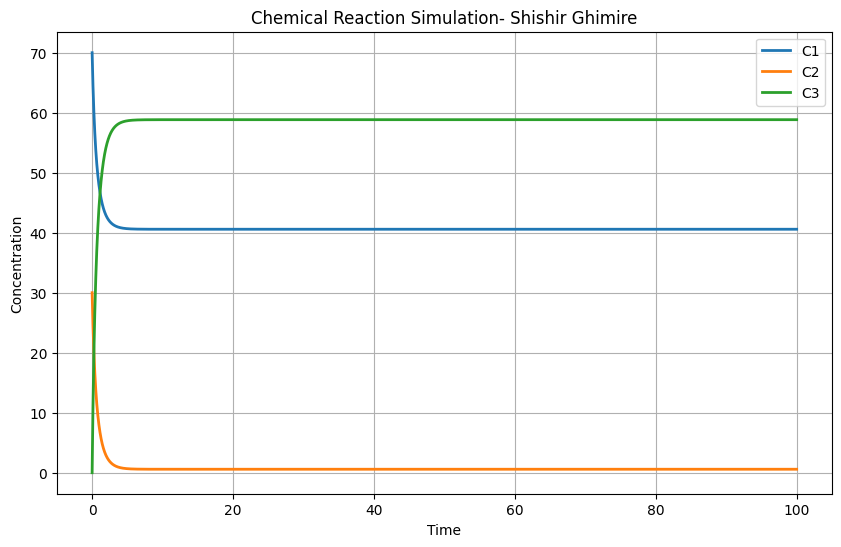

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Import pandas

print("Simulating reaction of chemicals c1, c2 and c3...")

# Simulation parameters
dt = 0.001
time = 100.0
steps = int(time / dt)

k1 = 0.025
k2 = 0.01

# Arrays to store results
t_values = np.linspace(0, time, steps + 1)
c1 = np.zeros(steps + 1)
c2 = np.zeros(steps + 1)
c3 = np.zeros(steps + 1)

# Initial values
c1[0] = 70.0
c2[0] = 30.0
c3[0] = 0.0

# Simulation loop (Euler's method)
for i in range(steps):
    c1[i + 1] = c1[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c2[i + 1] = c2[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c3[i + 1] = c3[i] + 2.0 * (k1 * c1[i] * c2[i] - k2 * c3[i]) * dt

# Save data to file
output_data = np.column_stack((t_values, c1, c2, c3))
np.savetxt("lab1_output.txt", output_data, fmt="%.6f", header="time  c1  c2  c3")

print("Simulation completed. File saved as lab1_output.txt.")

# Read the generated file and display its content
print("\nReading the generated file 'lab1_output.txt':")

df_output = pd.read_csv("lab1_output.txt", sep='\s+', skiprows=1, names=['time', 'c1', 'c2', 'c3'])
display(df_output.head(200)) # Display the first 5 rows

# ------------------------------
# Plot the results
# ------------------------------
plt.figure(figsize=(10, 6))
plt.plot(t_values, c1, label="C1", linewidth=2)
plt.plot(t_values, c2, label="C2", linewidth=2)
plt.plot(t_values, c3, label="C3", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Chemical Reaction Simulation- Shishir Ghimire")
plt.legend()
plt.grid(True)
plt.show()